In [1]:
import json
import torch

from core.models.LightningDiT import LightningDiT, LightningDiTConfig
from core.models.MAE import MAEResNet, FeatureExtractor

from core.datasets.pokemon_dataset import PokemonDataset
from core.training.train import train_drifting
from core.models.utils import prepare_vae, get_number_of_parameters

/home/msst/Utils/miniconda3/envs/qenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
img_size=128

In [3]:
vae_name = "flux-vae"

vae_kwargs = {
    "device_map": "cuda:0",
    "torch_dtype": torch.bfloat16,
}

vae, latent_shape = prepare_vae(
    vae_name="flux_vae",
    path_to_vae="./checkpoints/flux_vae",
    img_size=img_size,
    vae_kwargs=vae_kwargs
)
vae = torch.compile(vae, mode="reduce-overhead")

In [4]:
config_path = "./configs/LightningDiT_configs/LightningDiT-S2_flux-vae_img128.json"

with open(config_path, "r") as f:
    config_dict = json.load(f)

vit_config = LightningDiTConfig.from_dict(config_dict)
vit = LightningDiT(vit_config).cuda()

# vit = LightningDiT.from_pretrained(
#     "/home/msst/repo/drifting/checkpoints/CelebA/transformer_img128_ps2_flux-vae_newloss/transformer_step2000"
# ).cuda()

opt = torch.optim.AdamW(
    vit.parameters(), 
    lr=2e-4,
    betas=(0.9, 0.95),
    weight_decay=0.02,
)

In [5]:
mae = MAEResNet.from_pretrained(
    # "./checkpoints/CelebA/pixel-MAE_img128_ch128_mask0.5_patch1/epoch-20"
    "./checkpoints/CelebA/latent-MAE-flux-vae_img128_ch384/epoch-92"
)
feature_encoder = FeatureExtractor(
    encoder=mae.encoder.to(torch.bfloat16).cuda(),
    input_patch_size=mae.input_patch_size,
    every_k_block=None, #2
)
feature_encoder = torch.compile(feature_encoder)

In [6]:
def prepare_save_path(
        dataset_type,
        img_size,
        pixel_features,
        vae_name,
        batch_size,
        gradient_accumulation,
        samples_block,
):
    if pixel_features:
        mae_label = "pixel-MAE"
    else:
        mae_label = "latent-MAE"
    
    _effective_bs = batch_size * gradient_accumulation
    n_samples_blocks = _effective_bs // samples_block
    assert _effective_bs == n_samples_blocks * samples_block

    return f"checkpoints/{dataset_type}/transformer_img{img_size}_{vae_name}_{mae_label}_{samples_block}x{n_samples_blocks}"

Saved image to checkpoints/CelebA/transformer_img128_flux-vae_latent-MAE_32x16/gen_images_1250.png


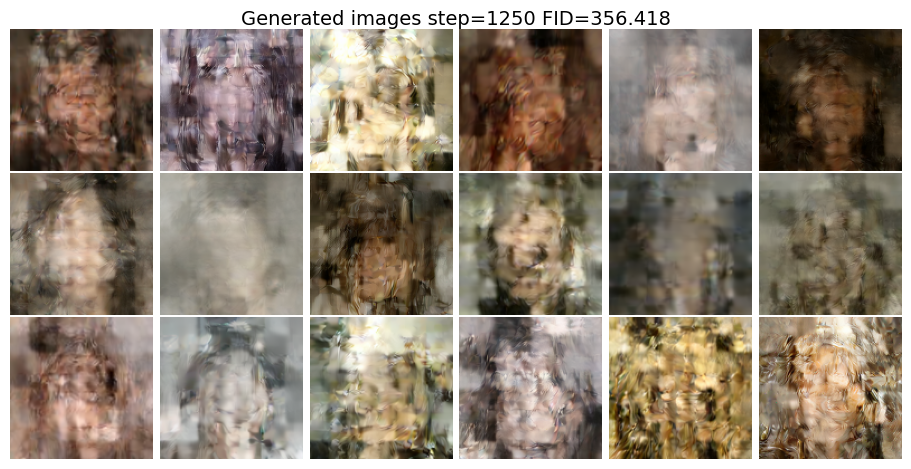

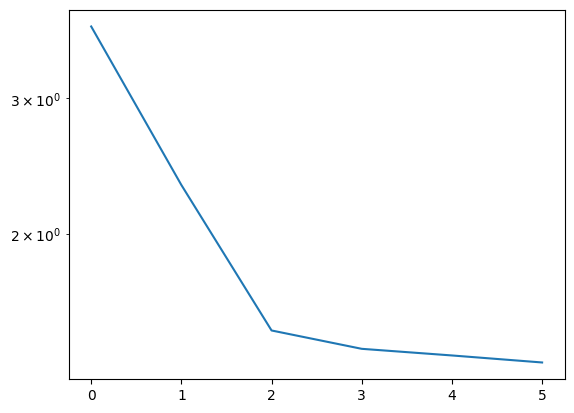

  1%|▏         | 1347/100000 [09:45<11:19:46,  2.42it/s, loss=1.35e+00]

In [ ]:
batch_size=128
gradient_accumulation=4
samples_block=32
pixel_features=feature_encoder.input_patch_size != 1

dataset_path = "/home/msst/repo/drifting/data/CelebA"
dataset_type = "CelebA"
# dataset_path = "/home/msst/repo/drifting/data/pokemon/images"
# dataset_type = "pokemon"

save_path=prepare_save_path(
    dataset_type=dataset_type,
    img_size=img_size,
    pixel_features=pixel_features,
    vae_name=vae_name,
    batch_size=batch_size,
    gradient_accumulation=gradient_accumulation,
    samples_block=samples_block
)


dataset = PokemonDataset(
    root_dir=dataset_path, 
    img_size=img_size, 
    dataset_type=dataset_type
)

train_drifting(
    dataset=dataset,
    feature_encoder=feature_encoder,
    pixel_features=pixel_features,
    transformer=vit,
    vae=vae,
    opt=opt,
    noise_shape=latent_shape,
    T_list=[0.02, 0.05, 0.2],
    samples_block=samples_block,
    batch_size=batch_size,
    gradient_accumulation=gradient_accumulation,
    training_steps=10**5,
    val_step=250,
    samples_to_compute_fid=512,
    seed=None,
    save_step=1000,
    loss_scaling=1.0e3,
    training_device="cuda:0",
    training_dtype=torch.bfloat16,
    save_path=save_path,
)
